## **5° Module**: TT - Transformations (C1–C5)
* September 24°, 2026
#### ESCOM - IPN:

#### *B.S. in Computer Science*
> Miguel Alexander Sanchez Garcia


#### **0° Introduction**

This module creates five 12-dimensional representations from the angular vectors of Module 4. Masses and calcifications are processed independently, and every learned transformation is fitted only on the training split.

C1 preserves the input; C2 is the full-dimensional PCA null control; C3 is RBF KernelPCA with a training-pair median bandwidth. C4 and C5 calculate exact local Z expectations after the same fixed ansatz, using ZZ and Pauli X/ZZ feature maps, respectively. The ansatz converts input-dependent phases into Z-basis observables; all quantum values are direct Statevector calculations, with no sampling noise.


#### **0°a Conditions and downstream use**

Module 5 stores one row-aligned, 12-dimensional representation for every lesion. Module 6 consumes these representations for separability analysis and Module 7 consumes them for classification (D-030); keeping the representations on disk makes those later analyses compare exactly the same lesions and splits.

| Condition | Operation | Fitted on train only | Decision and role |
|---|---|---|---|
| C1 | Identity: the 12 angular inputs are retained. | Nothing. | Reference representation. |
| C2 | PCA from 12 to 12 dimensions: centering followed by an orthogonal rotation. | PCA mean and rotation. | D-016; a null control because orthogonal rotation preserves Euclidean distances after common centering. It therefore validates that later distance-based results are not created by a dimensionality-reducing baseline. |
| C3 | KernelPCA with an RBF kernel. | KernelPCA and gamma, where gamma is the inverse of twice the median training-pair squared distance. | D-027; gamma is 0.0322201557 for masses and 0.0320888783 for calcifications. |
| C4 | Exact local Z expectations after the ZZ feature map and the fixed ansatz. | Nothing from labels; the circuit parameters are fixed. | D-013 and D-014. |
| C5 | Exact local Z expectations after the Pauli feature map with X and ZZ terms and the same fixed ansatz. | Nothing from labels; the circuit parameters are fixed. | D-015. With one repetition the X term acts on the state after the Hadamard layer, which is an eigenstate of X, so it only adds a global phase: C5 prepares exactly the state of a ZZ-only map (H-034). C4 versus C5 therefore compares having or not having a first-order term, with the same ZZ coupling. How to interpret or replace C5 is pending (Q-012). |

Architecture B fixes theta by drawing the ansatz parameters once with seed 42 and does not train them (D-014). Consequently, none of the five transformations uses labels: C1 has no fitted object, C2 and C3 fit only feature values from train, and C4/C5 use the predeclared seed rather than an optimization target.


#### **1° Setup**

**a.** Import the libraries for exact quantum-state evaluation, classical transformations, and reporting.


In [1]:
import json
import time
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import qiskit, qiskit_aer, qiskit_machine_learning, sklearn
from qiskit.circuit.library import pauli_feature_map, real_amplitudes, zz_feature_map
from qiskit.quantum_info import SparsePauliOp, Statevector
from sklearn.decomposition import KernelPCA, PCA
from sklearn.metrics import pairwise_distances

SEED, N_QUBITS = 42, 12
ROOT = Path('/Users/alexander_san/TT')
IN_DIR = ROOT / 'Data/processed/m4'
OUT_DIR = ROOT / 'Data/processed/m5'
RESULTS_DIR = ROOT / 'Code/results'
FIG_DIR = ROOT / 'Docs/Figures'
for directory in (OUT_DIR, RESULTS_DIR, FIG_DIR):
    directory.mkdir(parents=True, exist_ok=True)
FINDINGS = ['mass', 'calcification']
X_COLUMNS = [f'x_{i:02d}' for i in range(1, 13)]
ID_COLUMNS = ['case_id', 'patient_id', 'split', 'label', 'fold', 'crop_check']
data = {ft: pd.read_parquet(IN_DIR / f'x_{ft}.parquet') for ft in FINDINGS}
print('qiskit', qiskit.__version__, '| numpy', np.__version__, '| scikit-learn', sklearn.__version__)
for ft, frame in data.items(): print(ft, len(frame), 'lesions;', int((frame.split == 'train').sum()), 'train')


qiskit 2.3.0 | numpy 2.2.6 | scikit-learn 1.7.2
mass 1696 lesions; 1318 train
calcification 1872 lesions; 1546 train


#### **2° Transformations**

**a.** Fit the classical controls only on train rows. A full PCA is a centered orthogonal coordinate change, so its pairwise Euclidean distances must match C1. C3 obtains gamma as the inverse of twice the median squared distance over distinct training pairs.

**b.** Build the circuits. Parameters are assigned by their Parameter objects, never by positions in a composed circuit. The exact local Z values are obtained from little-endian state probabilities: for each qubit, probability of bit zero minus probability of bit one.


#### **2°a Circuit structure**

The state is prepared as ansatz(theta) after the feature map, so the feature map first encodes the angular input and the fixed real-amplitudes layer then exposes phase-dependent interference to local Z measurements. This order is material: a diagonal phase encoding alone changes relative phases but not computational-basis probabilities.

For `zz_feature_map(12, reps=1)`, `decompose()` shows one Hadamard gate on each qubit, followed by the single-qubit phase P(2 x_i). For every one of the 66 unordered qubit pairs, it shows CX, then P(2 (pi - x_i) (pi - x_j)) on the target, then CX; this is the explicit compute-phase-uncompute pattern for the ZZ term.

For `pauli_feature_map(12, reps=1, paulis=['X', 'ZZ'])`, the decomposed circuit displays, on each wire, the initial Hadamard and then the X first-order encoding as H, P(2 x_i), H. The decomposition retains the consecutive Hadamards as written rather than simplifying them; the observed gate sequence, not an assumed abstract replacement, is what is used here. Its ZZ pair block is the same CX, P(2 (pi - x_i) (pi - x_j)), CX pattern as C4. The X term, however, encodes nothing here: after the Hadamard layer every qubit is in |+>, an eigenstate of X, so the rotation H P(2 x_i) H only multiplies each qubit by a phase, and on this product state those phases combine into a single global phase that no measurement or fidelity can detect. With one repetition C5 is therefore identical to a ZZ-only map; the inspection cell below confirms fidelity 1 on real lesions (H-034).

`real_amplitudes(12, reps=1)` has exactly 24 free parameters: an initial layer of 12 RY rotations, one entangling layer with Qiskit's default `reverse_linear` pattern, which is 11 CX gates between neighbouring qubits, and a final layer of 12 RY rotations. In the decomposed display Qiskit writes each RY as R(theta, pi/2), which is the same real rotation in a different gate notation.

The ansatz is necessary (H-013). The feature maps write phases, while a Z measurement only reads computational-basis probabilities; without a non-diagonal layer after the encoding, those probabilities remain uniform and every local Z expectation is zero.


In [2]:
def median_gamma(x_train):
    sq = pairwise_distances(x_train, metric='sqeuclidean')
    median = np.median(sq[np.triu_indices_from(sq, k=1)])
    if not np.isfinite(median) or median <= 0: raise ValueError('nonpositive training median')
    return 1.0 / (2.0 * median)

def columns(values, name):
    return pd.DataFrame(values, columns=[f'{name}_{i:02d}' for i in range(1, 13)])

ansatz = real_amplitudes(N_QUBITS, reps=1)
theta = np.random.default_rng(SEED).uniform(0, 2*np.pi, ansatz.num_parameters)
feature_maps = {'C4': zz_feature_map(N_QUBITS, reps=1), 'C5': pauli_feature_map(N_QUBITS, reps=1, paulis=['X', 'ZZ'])}
basis = np.arange(2**N_QUBITS)[:, None]
signs = 1.0 - 2.0 * ((basis >> np.arange(N_QUBITS)) & 1)

def exact_embedding(feature_map, x):
    values = {p: float(v) for p, v in zip(feature_map.parameters, x)}
    values.update({p: float(v) for p, v in zip(ansatz.parameters, theta)})
    circuit = feature_map.compose(ansatz).assign_parameters(values, inplace=False)
    return Statevector.from_instruction(circuit).probabilities() @ signs

def embed(feature_map, x):
    start = time.perf_counter()
    result = np.vstack([exact_embedding(feature_map, row) for row in x])
    return result, time.perf_counter() - start


In [ ]:
# Read-only circuit inspection; it does not change data, parameters, or saved outputs.
# Gate counts of the 12-qubit circuits, and the same structures drawn for 2 qubits.
from qiskit.quantum_info import Statevector
for name, circuit in {**feature_maps, 'ansatz': ansatz}.items():
    print(f'{name} (12 qubits): {dict(circuit.decompose().count_ops())}')
small = {'C4': zz_feature_map(2, reps=1), 'C5': pauli_feature_map(2, reps=1, paulis=['X', 'ZZ']), 'ansatz': real_amplitudes(2, reps=1)}
for name, circuit in small.items():
    print(f'\n{name}, drawn for 2 qubits')
    print(circuit.decompose().draw(output='text'))

# H-034: with reps=1 the X term of C5 acts on |+>, an eigenstate of X, so C5 prepares the same state as a ZZ-only map
zz_only = pauli_feature_map(12, reps=1, paulis=['ZZ'])
state = lambda fm, x: Statevector(fm.assign_parameters(dict(zip(fm.parameters, x))))
x5 = data['mass'][X_COLUMNS].to_numpy(float)[:5]
fid = [abs(state(feature_maps['C5'], x).inner(state(zz_only, x)))**2 for x in x5]
print('\nFidelity between the C5 state and a ZZ-only state, first 5 mass lesions:', np.round(fid, 12))


C4 (12 qubits): {'cx': 132, 'u': 90}
C5 (12 qubits): {'cx': 132, 'u': 114}
ansatz (12 qubits): {'r': 24, 'cx': 11}

C4, drawn for 2 qubits
   ┌────────────┐┌───────────────┐                                         »
0: ┤ U(π/2,0,π) ├┤ U(0,0,2*x[0]) ├──■──────────────────────────────────────»
   ├────────────┤├───────────────┤┌─┴─┐┌──────────────────────────────────┐»
1: ┤ U(π/2,0,π) ├┤ U(0,0,2*x[1]) ├┤ X ├┤ U(0,0,(-π + x[0])*(-π + x[1])*2) ├»
   └────────────┘└───────────────┘└───┘└──────────────────────────────────┘»
«        
«0: ──■──
«   ┌─┴─┐
«1: ┤ X ├
«   └───┘

C5, drawn for 2 qubits
   ┌────────────┐┌────────────┐┌───────────────┐┌────────────┐     »
0: ┤ U(π/2,0,π) ├┤ U(π/2,0,π) ├┤ U(0,0,2*x[0]) ├┤ U(π/2,0,π) ├──■──»
   ├────────────┤├────────────┤├───────────────┤├────────────┤┌─┴─┐»
1: ┤ U(π/2,0,π) ├┤ U(π/2,0,π) ├┤ U(0,0,2*x[1]) ├┤ U(π/2,0,π) ├┤ X ├»
   └────────────┘└────────────┘└───────────────┘└────────────┘└───┘»
«                                            
«0: ───────

#### **2°b Exact expectation values**

A local Z expectation is a deterministic number specified by the prepared state: it is the probability of bit i being zero minus the probability of bit i being one. That exactness is a property of the statevector formalism, not a claim about finite-shot hardware measurements.

The implementation obtains those probabilities directly from `Statevector`, using Qiskit's little-endian qubit indexing, and independently validates selected entries with `SparsePauliOp`. This avoids an implementation-specific default documented in H-019: `EstimatorQNN` supplies a nonzero default precision, and a statevector estimator given nonzero precision adds Gaussian noise. Direct `Statevector` evaluation has neither estimator precision nor sampling noise.


**c.** Transform every lesion, including test lesions, after fitting only on train. Quantum timing surrounds only the exact embedding pass, which makes it an interpretable time-per-lesion record.


In [3]:
outputs, meta_rows, summary_rows, check_rows = {}, [], [], []
for ft, frame in data.items():
    x = frame[X_COLUMNS].to_numpy(float)
    train = frame.split.eq('train').to_numpy()
    pca = PCA(n_components=12, random_state=SEED).fit(x[train])
    c1, c2 = x.copy(), pca.transform(x)
    gamma = median_gamma(x[train])
    c3 = KernelPCA(n_components=12, kernel='rbf', gamma=gamma).fit(x[train]).transform(x)
    c4, c4_time = embed(feature_maps['C4'], x)
    c5, c5_time = embed(feature_maps['C5'], x)
    transformed = {'C1': c1, 'C2': c2, 'C3': c3, 'C4': c4, 'C5': c5}
    output = frame[ID_COLUMNS].copy()
    for name, value in transformed.items(): output = pd.concat([output, columns(value, name)], axis=1)
    output.to_parquet(OUT_DIR / f'emb_{ft}.parquet', index=False)
    outputs[ft] = output
    meta_rows.append({'finding_type': ft, 'gamma': gamma, 'n_train': int(train.sum())})
    elapsed = {'C1': 0., 'C2': 0., 'C3': 0., 'C4': c4_time, 'C5': c5_time}
    for name, value in transformed.items():
        summary_rows.append({'finding_type': ft, 'condition': name, 'mean': float(value.mean()), 'std_mean_by_dimension': float(value.std(axis=0).mean()), 'minimum': float(value.min()), 'maximum': float(value.max()), 'total_time_seconds': elapsed[name]})
    order_ok, nan_count = output.case_id.equals(frame.case_id), int(output.isna().sum().sum())
    check_rows.append({'finding_type': ft, 'acceptance': 1, 'check': 'row count, case_id order, and missing values', 'value': f'rows={len(output)}; expected={len(frame)}; same_order={order_ok}; nan={nan_count}', 'passed': len(output)==len(frame) and order_ok and nan_count==0})
    delta = float(np.max(np.abs(pairwise_distances(c1[train])-pairwise_distances(c2[train]))))
    check_rows.append({'finding_type': ft, 'acceptance': 2, 'check': 'maximum C1/C2 train pairwise-distance difference', 'value': delta, 'passed': delta <= 1e-9})
    rng = np.random.default_rng(SEED)
    sample20 = rng.choice(len(frame), 20, replace=False)
    for name, fmap in feature_maps.items():
        value, max_delta = transformed[name], 0.
        for index in sample20:
            values = {p: float(v) for p, v in zip(fmap.parameters, x[index])}
            values.update({p: float(v) for p, v in zip(ansatz.parameters, theta)})
            sv = Statevector.from_instruction(fmap.compose(ansatz).assign_parameters(values, inplace=False))
            expected = np.array([float(np.real(sv.expectation_value(SparsePauliOp.from_sparse_list([('Z',[i],1.0)], num_qubits=12)))) for i in range(12)])
            max_delta = max(max_delta, float(np.max(np.abs(expected-value[index]))))
        check_rows.append({'finding_type': ft, 'acceptance': 3, 'check': f'{name} SparsePauliOp validation on 20 seeded lesions', 'value': max_delta, 'passed': max_delta <= 1e-12})
        bounds, min_std = bool(np.all(value >= -1) and np.all(value <= 1)), float(value.std(axis=0).min())
        check_rows.append({'finding_type': ft, 'acceptance': 4, 'check': f'{name} bounds and positive standard deviation in all dimensions', 'value': f'in_bounds={bounds}; min_std={min_std:.17g}', 'passed': bounds and min_std > 0})
        sample5 = rng.choice(len(frame), 5, replace=False)
        repeat = np.vstack([exact_embedding(fmap, x[index]) for index in sample5])
        reproducibility = float(np.max(np.abs(repeat-value[sample5])))
        check_rows.append({'finding_type': ft, 'acceptance': 5, 'check': f'{name} exact recomputation on 5 seeded lesions', 'value': reproducibility, 'passed': reproducibility == 0.})
    check_rows.append({'finding_type': ft, 'acceptance': 6, 'check': 'reported C3 median-heuristic gamma', 'value': gamma, 'passed': bool(np.isfinite(gamma) and gamma > 0)})
    print(f'{ft}: gamma={gamma:.10f}; C4={c4_time/len(frame):.6f} s/lesion; C5={c5_time/len(frame):.6f} s/lesion')


mass: gamma=0.0322201557; C4=0.007274 s/lesion; C5=0.007940 s/lesion


calcification: gamma=0.0320888783; C4=0.007419 s/lesion; C5=0.007982 s/lesion


#### **3° Verification, records, and figure**

**a.** Save seeds, versions, and learned bandwidths alongside the numerical acceptance checks. These records make the five representations independently reproducible.


,finding_type,condition,mean,std_mean_by_dimension,minimum,maximum,total_time_seconds
0,mass,C1,1.565805,0.902221,0.000000,3.141593,0.000000
1,mass,C2,0.002228,0.596894,-5.161721,5.010463,0.000000
2,mass,C3,-0.000352,0.148150,-0.653179,0.653674,0.000000
3,mass,C4,0.005806,0.056497,-0.624392,0.578149,12.336287
4,mass,C5,0.005704,0.055185,-0.616719,0.637886,13.465736
5,calcification,C1,1.568122,0.905056,0.000000,3.141593,0.000000
6,calcification,C2,0.006467,0.603038,-4.840499,5.260160,0.000000
7,calcification,C3,0.001553,0.145772,-0.624802,0.696108,0.000000
8,calcification,C4,0.002247,0.047746,-0.618034,0.572404,13.888383
9,calcification,C5,0.002227,0.046362,-0.621091,0.632204,14.943204


,finding_type,acceptance,check,value,passed
0,mass,1,"row count, case_id order, and missing values",rows=1696; expected=1696; same_order=True; nan=0,True
1,mass,2,maximum C1/C2 train pairwise-distance difference,0.0,True
2,mass,3,C4 SparsePauliOp validation on 20 seeded lesions,0.0,True
3,mass,4,C4 bounds and positive standard deviation in a...,in_bounds=True; min_std=0.020676349028419465,True
4,mass,5,C4 exact recomputation on 5 seeded lesions,0.0,True
5,mass,3,C5 SparsePauliOp validation on 20 seeded lesions,0.0,True
6,mass,4,C5 bounds and positive standard deviation in a...,in_bounds=True; min_std=0.017867628503247461,True
7,mass,5,C5 exact recomputation on 5 seeded lesions,0.0,True
8,mass,6,reported C3 median-heuristic gamma,0.03222,True
9,calcification,1,"row count, case_id order, and missing values",rows=1872; expected=1872; same_order=True; nan=0,True


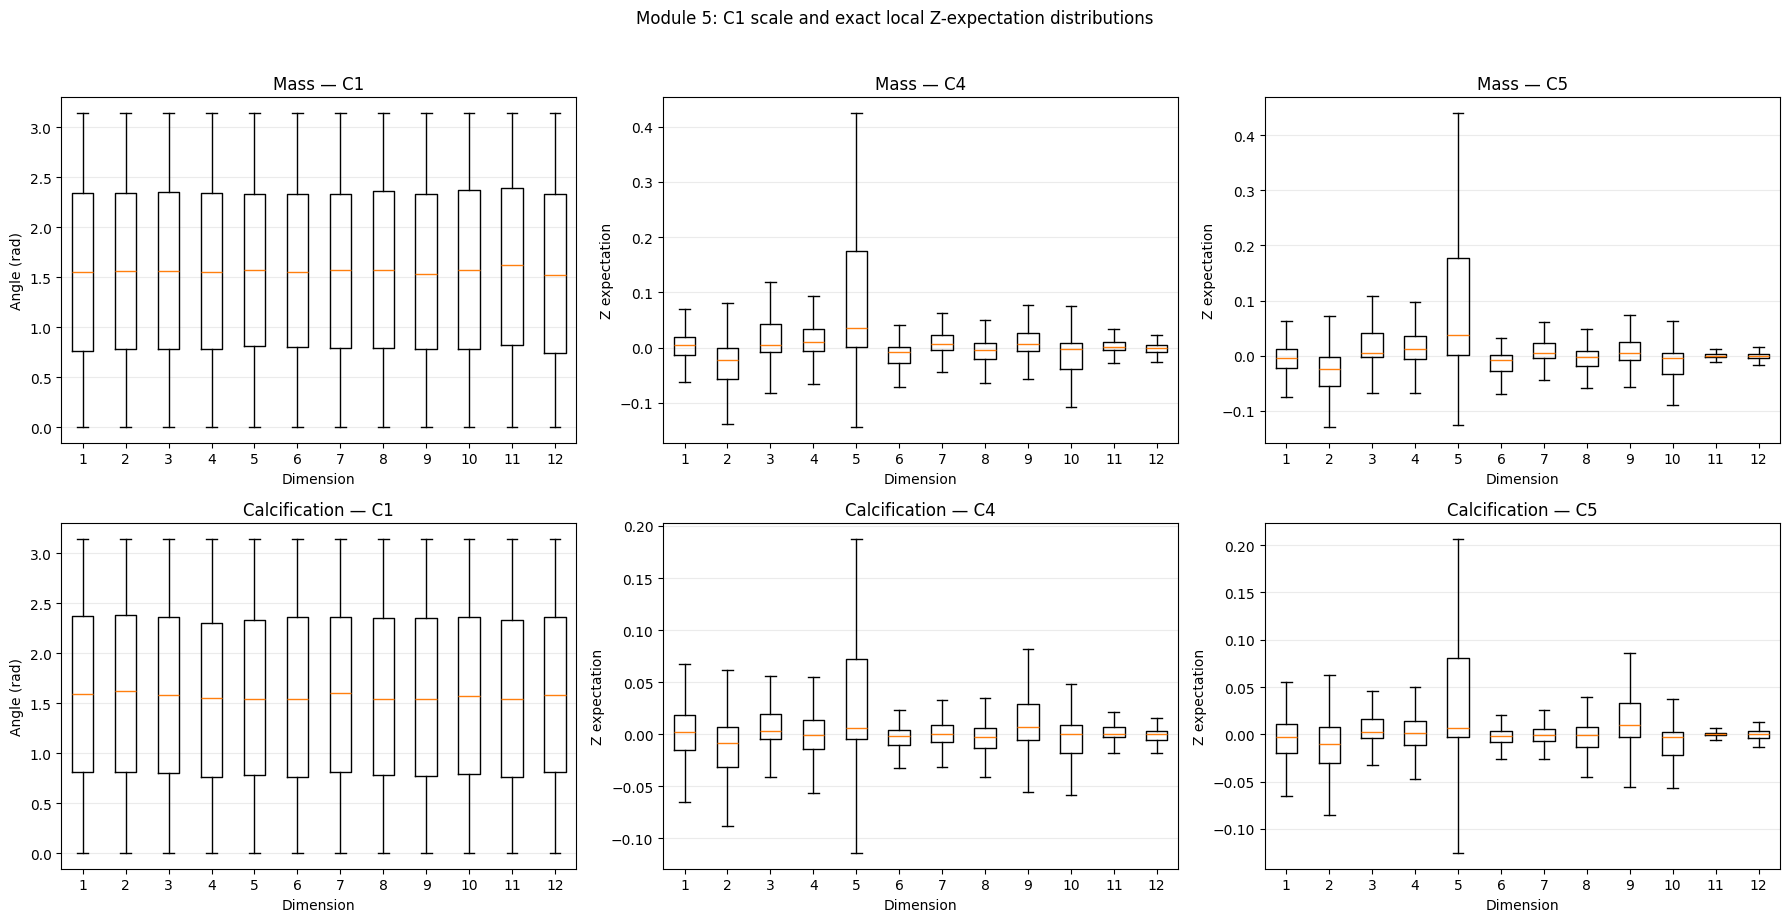

In [4]:
metadata = {'seed': SEED, 'theta': theta.tolist(), 'gamma_by_finding_type': {r['finding_type']: r['gamma'] for r in meta_rows}, 'versions': {'qiskit': qiskit.__version__, 'qiskit-aer': qiskit_aer.__version__, 'qiskit-machine-learning': qiskit_machine_learning.__version__, 'scikit-learn': sklearn.__version__, 'numpy': np.__version__}, 'quantum_evaluation': 'direct Statevector with parameter-object dictionaries; no estimator primitive'}
with open(OUT_DIR/'emb_meta.json', 'w', encoding='utf-8') as file: json.dump(metadata, file, indent=2)
summary, verifications = pd.DataFrame(summary_rows), pd.DataFrame(check_rows)
summary.to_csv(RESULTS_DIR/'5a_resumen.csv', index=False)
verifications.to_csv(RESULTS_DIR/'5a_verificaciones.csv', index=False)
display(summary)
display(verifications)

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
for row, ft in enumerate(FINDINGS):
    for col, name in enumerate(['C1','C4','C5']):
        ax = axes[row, col]; cols = [f'{name}_{i:02d}' for i in range(1,13)]
        ax.boxplot(outputs[ft][cols].to_numpy(), showfliers=False)
        ax.set_title(f'{ft.capitalize()} — {name}'); ax.set_xlabel('Dimension')
        ax.set_ylabel('Angle (rad)' if name=='C1' else 'Z expectation'); ax.grid(axis='y', alpha=.25)
fig.suptitle('Module 5: C1 scale and exact local Z-expectation distributions', y=1.02)
fig.tight_layout(); fig.savefig(FIG_DIR/'M5_embeddings.png', dpi=220, bbox_inches='tight'); plt.show()


#### **4° Consequence**

The verification table reports the observed output completeness, PCA distance agreement, independent Pauli-operator agreement, bounds, variability, reproducibility, and C3 bandwidth. The summary table reports ranges, average per-dimension variation, and exact-evaluation times. The figure compares the observed C1 angular scale with the local Z-expectation distributions of C4 and C5 for both subsets.


#### **4°a Numerical consequence**

The RBF median-heuristic gamma values were 0.0322201557 for masses and 0.0320888783 for calcifications. Exact C4/C5 evaluation took 0.007273754/0.007939703 seconds per lesion for masses and 0.007419008/0.007982481 seconds per lesion for calcifications.

For masses, the across-lesion standard deviations over the 12 dimensions ranged from 0.893850 to 0.918023 for C1, from 0.020682 to 0.107500 for C4, and from 0.017873 to 0.108446 for C5. For calcifications, they ranged from 0.897667 to 0.912850 for C1, from 0.017023 to 0.092700 for C4, and from 0.013700 to 0.095878 for C5.

All six acceptance checks passed for both subsets: output rows, order, and missing values were correct; the maximum C1/C2 train-distance differences were 8.2712e-14 for masses and 8.9179e-14 for calcifications; all 20-lesion Pauli validations were at most 1.6376e-15; every C4/C5 value was within [-1, 1] and every dimension had positive variation; five-lesion recomputations had difference exactly zero; and both positive gamma values were recorded. These numbers describe representation construction and verification only.
